# Tarea 04 — Visualización de Datos con Matplotlib

**Instrucciones:** Completa cada celda de código con tu respuesta.  
Usarás la interfaz orientada a objetos de Matplotlib (`fig, ax = plt.subplots()`).

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Dataset de trabajo
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)

---
## Parte 1 — Figura y ejes

**P1.** Crea una figura con `plt.subplots()` de tamaño 8×5.  
Haz un gráfico de línea con los primeros 20 valores de `sepal_length`.  
Agrega título `"Longitud del sépalo"` y etiquetas en ambos ejes.

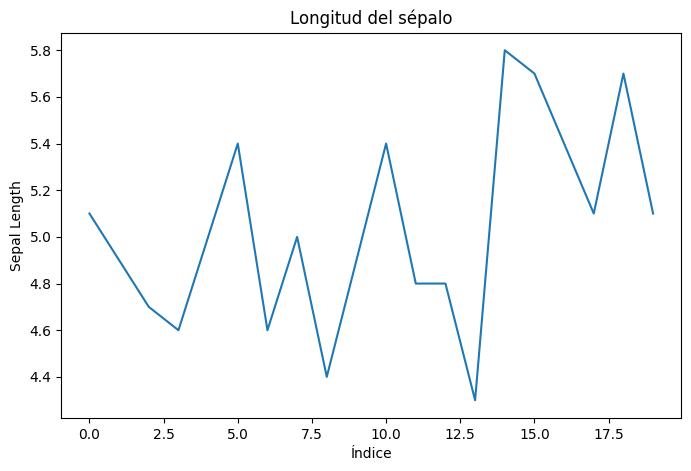

In [9]:
# Tu respuesta aquí

# Creamos el lienzo de la figura
fig, ax = plt.subplots(figsize=(8, 5)) # Se usa "figsize" para definir el tamaño del grafico (ancho x alto)

# Tomamos los primeros 20 valores
valores = df["sepal_length"][:20]

# Graficamos las líneas
ax.plot(valores)

# Etiquetas
ax.set_title("Longitud del sépalo")
ax.set_xlabel("Índice")
ax.set_ylabel("Sepal Length")

plt.show()

**Interpretación:** La longitud del pétalo oscila entre un mínimo cercano a 4.3 y un máximo cercano a 5.8, además, se oberva una variación, la línea baja y sube sin un patrón definido.

---
## Parte 2 — Gráfico de barras

**P2.** Calcula el promedio de `petal_length` por especie (`species`) y guárdalo en una variable.  
Luego crea un **gráfico de barras vertical** con esos promedios.  
Agrega título y etiquetas en ambos ejes.

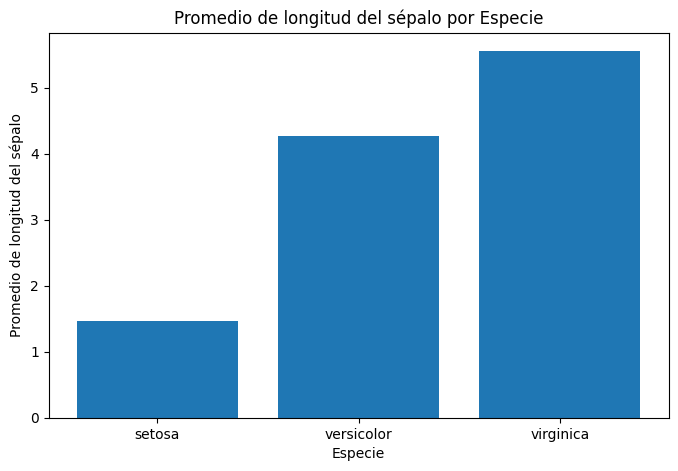

In [15]:
# Tu respuesta aquí
promedios = df.groupby("species")["petal_length"].mean()

# Creamos el lienzo de la figura
fig, ax = plt.subplots(figsize=(8, 5))

#Graficamos las barras
ax.bar(promedios.index, promedios.values)

# Título y etiquetas
ax.set_title("Promedio de longitud del sépalo por Especie")
ax.set_xlabel("Especie")
ax.set_ylabel("Promedio de longitud del sépalo")

plt.show()

**Interpretación:** Existe una clara diferencia entre la longitud del sépalo entre las especie, siendo la especie virginica la que tiene el promedio más alto, es decir que sus sépalos son más largos.

---
## Parte 3 — Dispersión (scatter plot)

**P3.** Crea un **gráfico de dispersión** (scatter) con `sepal_length` en el eje X y `sepal_width` en el eje Y.  
Usa un color diferente para cada especie (puedes filtrar el DataFrame tres veces o usar un bucle).  
Agrega leyenda, título y etiquetas.

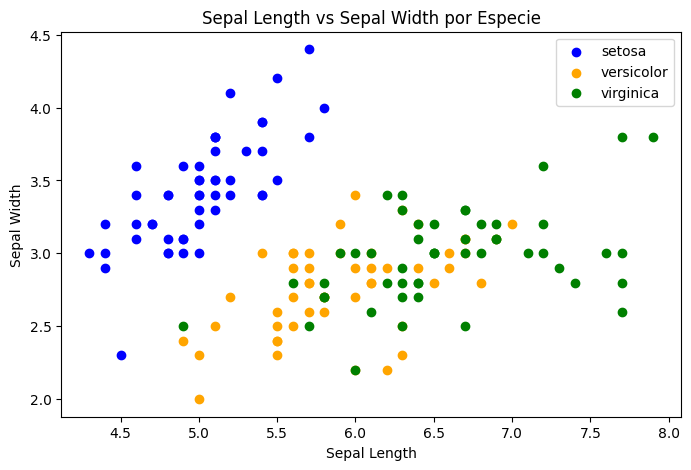

In [14]:
especies = df["species"].unique()
colores = ["blue", "orange", "green"]

fig, ax = plt.subplots(figsize=(8, 5))

# Tu respuesta aquí: itera sobre especies y colores para graficar cada grupo

# Graficar cada especie
for especie, color in zip(especies, colores):
     subset = df[df["species"] == especie]
     ax.scatter(
        subset["sepal_length"],
        subset["sepal_width"],
        label=especie,
        color=color)

# Etiquetas y título
ax.set_title("Sepal Length vs Sepal Width por Especie")
ax.set_xlabel("Sepal Length")
ax.set_ylabel("Sepal Width")

# Leyenda
ax.legend()

plt.show()

---
## Parte 4 — Histograma

**P4.** Crea un **histograma** de la columna `petal_width` con 15 bins.  
Agrega una línea vertical punteada en el valor de la media con `ax.axvline()`.  
Agrega título y etiquetas.

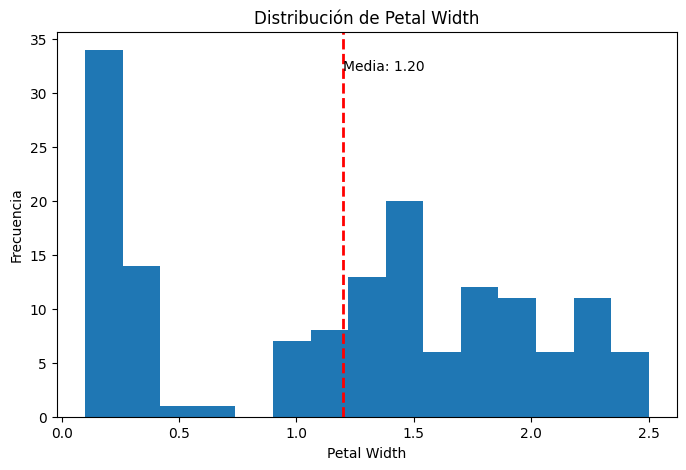

In [20]:
# Tu respuesta aquí

# Calculamos la media
media = df["petal_width"].mean()

# Creamos el lienzo de la figura
fig, ax = plt.subplots(figsize=(8, 5))

# Histograma con 15 intervalos
ax.hist(df["petal_width"], bins=15)

# Línea vertical en la media punteada
ax.axvline(media, linestyle="--", color= "red", linewidth=2)
ax.text(media, ax.get_ylim()[1]*0.9, f"Media: {media:.2f}")

# Título y etiquetas
ax.set_title("Distribución de Petal Width")
ax.set_xlabel("Petal Width")
ax.set_ylabel("Frecuencia")

plt.show()


---
## Parte 5 — Guardar figura

**P5.** Recrea el gráfico de barras de P2 y guárdalo como imagen PNG en `output/promedios_iris.png`.  
Usa `dpi=100` y `bbox_inches="tight"`.

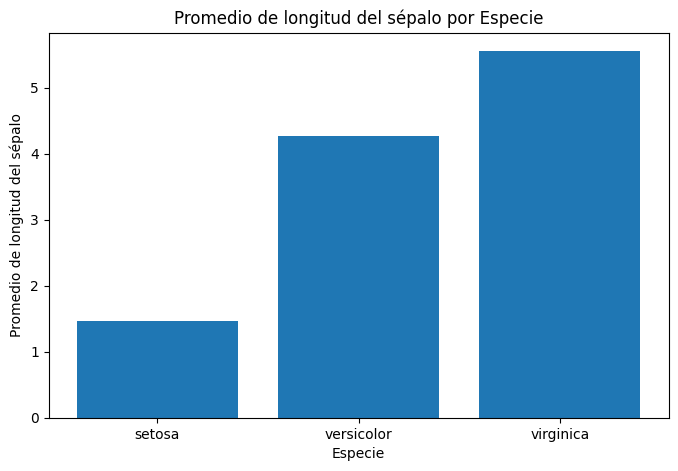

<Figure size 640x480 with 0 Axes>

In [21]:
import os
os.makedirs("output", exist_ok=True) # Asegurar que la carpeta exista

# Tu respuesta aquí

#Calculamos promedios
promedios_especies = df.groupby("species")["petal_length"].mean()

# Creamos el lienzo de la figura
fig, ax = plt.subplots(figsize=(8, 5))

#Graficamos las barras
ax.bar(promedios_especies.index, promedios_especies.values)

# Título y etiquetas
ax.set_title("Promedio de longitud del sépalo por Especie")
ax.set_xlabel("Especie")
ax.set_ylabel("Promedio de longitud del sépalo")

plt.show()

# Guardar imagen
plt.savefig("output/promedios_iris.png", dpi=100, bbox_inches="tight")

# Mostrar gráfico
plt.show()